# Data Loading and Cleaning

## Dataset: Student Performance Dataset

This lab focuses on loading, inspecting, cleaning, and preparing the Student Performance dataset for machine learning tasks. The dataset contains students’ scores in mathematics, reading, and writing along with demographic and educational information.

The purpose of this lab is to understand how real-world datasets are prepared before applying machine learning models.




# 2. Dataset Overview and Problem Type

# Dataset Overview

The Student Performance dataset contains records of students and their scores in:

* Math
* Reading
* Writing

It also contains categorical information such as:

* Gender
* Race/Ethnicity
* Lunch type
* Test preparation course
* Parental level of education

# 3. Problem Type

This dataset can be used for:

* Regression → Predicting student scores
* Classification → Categorizing students into performance groups

For this lab, we will use:

* Target Variable (y): math score
* Features (X): Remaining columns

In [26]:
# 4. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Explanation

* pandas is used for data handling
* numpy is used for numerical operations
* matplotlib is used for visualization


In [27]:
# 5. Load the Dataset
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Explanation

We use pd.read_csv() to load the dataset into a DataFrame. The head() function displays the first five rows so we can inspect the dataset structure.

In [28]:
# 6. Initial Inspection of Dataset

## Check Dataset Shape
print('Dataset Shape:', df.shape)


Dataset Shape: (1000, 8)


## Explanation

* Rows represent observations
* Columns represent features/variables

In [29]:
## Check Data Types and Non-Null Values

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# Explanation

This helps us:

* Identify missing values
* Check data types
* Verify categorical and numerical columns

Expected Observation:

* Numerical columns should be integers
* Categorical columns should be objects


In [30]:
# 7. Summary Statistics
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Explanation

This provides:

* Mean
* Standard deviation
* Minimum and maximum values
* Quartiles

# Observations

* Check score distributions
* Identify possible outliers
* Understand overall student performance

In [31]:
# 8. Check Missing Values
missing_values = df.isnull().sum()
print(missing_values)

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


# Explanation

This checks whether any column contains missing values.

### Expected Observation

This dataset is generally clean and should contain no missing values.

In [32]:
# 9. Check Duplicate Rows
duplicates = df.duplicated().sum()
print('Duplicate Rows:', duplicates)

Duplicate Rows: 0


# Explanation

Duplicate rows can negatively affect analysis and machine learning models.


In [33]:
## Remove Duplicate Rows (if present)
if duplicates > 0:
    ndf.drop_duplicates(inplace=True)
    print('Duplicates Removed')
else:
    print('No Duplicate Rows Found')



No Duplicate Rows Found


In [34]:
# 10. Standardize Categorical Columns

## Convert Text to Lowercase and Remove Spaces
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].str.strip().str.lower()


# Explanation

This step:

* Removes extra spaces
* Converts text into consistent lowercase format
* Prevents issues during encoding and modeling



In [35]:
# 11. Verify Changes
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group b,bachelor's degree,standard,none,72,72,74
1,female,group c,some college,standard,completed,69,90,88
2,female,group b,master's degree,standard,none,90,95,93
3,male,group a,associate's degree,free/reduced,none,47,57,44
4,male,group c,some college,standard,none,76,78,75


# Explanation

This confirms that categorical values are standardized properly.


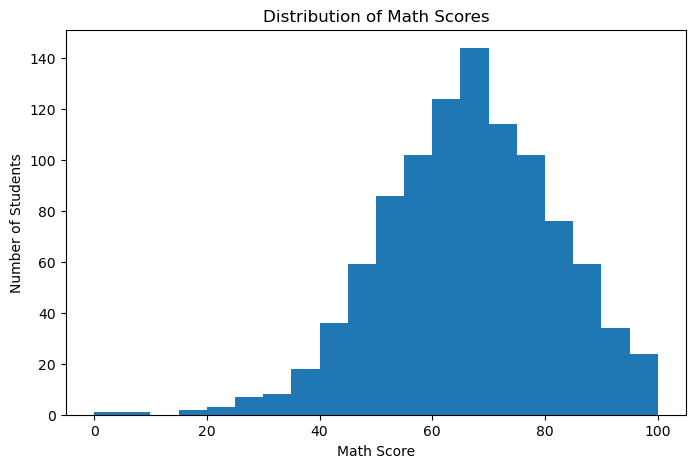

In [36]:
# 12. Visualize Score Distribution

## Histogram of Math Scores
plt.figure(figsize=(8,5))
plt.hist(df['math score'], bins=20)
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.title('Distribution of Math Scores')
plt.show()

## Observation

* Observe whether scores are normally distributed
* Identify skewness or unusual patterns



In [37]:
# 13. Relationship Between Parental Education and Scores
average_scores = df.groupby('parental level of education')['math score'].mean()
print(average_scores)

parental level of education
associate's degree    67.882883
bachelor's degree     69.389831
high school           62.137755
master's degree       69.745763
some college          67.128319
some high school      63.497207
Name: math score, dtype: float64


## Observation

Students with parents having higher educational qualifications may achieve better average scores.


In [38]:
# 14. Feature and Target Separation

## Define Target Variable
target_col = 'math score'

## Create Feature Matrix X and Target Vector y
X = df.drop(columns=[target_col])
y = df[target_col]

## Check Shapes
print('Features Shape:', X.shape)
print('Target Shape:', y.shape)


Features Shape: (1000, 7)
Target Shape: (1000,)


## Explanation

* `X` contains input features
* `y` contains the target variable

This is required for supervised machine learning.


In [39]:
# 15. Save Cleaned Dataset
df.to_csv('student_performance_cleaned.csv', index=False)
print('Cleaned Dataset Saved Successfully')


Cleaned Dataset Saved Successfully


# Explanation

The cleaned dataset is saved so it can be reused in future labs without repeating cleaning steps.

# 16. Final Summary

## Cleaning Steps Performed

* Loaded dataset using pandas
* Inspected dataset structure and data types
* Checked summary statistics
* Verified missing values
* Checked and removed duplicates
* Standardized categorical values
* Visualized score distributions
* Separated features and target variable
* Saved cleaned dataset


# Final Observation
The Student Performance dataset was already relatively clean. Only categorical standardization and integrity checks were required.

The dataset is now ready for:

* Exploratory Data Analysis (EDA)
* Machine Learning Models
* Regression Analysis
* Classification Tasks
